In [22]:
"""
Natural Gas Price Estimator
============================
JPMorgan Chase Quantitative Research Task
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════

DATA_PATH = '../data/Nat_Gas (5) (1).csv'
N_HARMONICS = 2                  # annual + semi-annual Fourier terms
SEASONAL_PERIOD = 12             # months


In [25]:
df = pd.read_csv(DATA_PATH)
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [10]:
# ══════════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════════

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, header=0, names=['Date', 'Price'])
    df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True)
    df = df.sort_values('Date').reset_index(drop=True)

    base_year  = df['Date'].dt.year.iloc[0]
    base_month = df['Date'].dt.month.iloc[0]
    df['t'] = (df['Date'].dt.year  - base_year)  * 12 + \
              (df['Date'].dt.month - base_month)
    return df

In [11]:
# ══════════════════════════════════════════════════════════════════
# FEATURE MATRIX  (intercept + trend + Fourier harmonics)
# ══════════════════════════════════════════════════════════════════

def build_features(t_vals: np.ndarray) -> np.ndarray:
    """
    Columns: [1,  t,
              sin(2π t/12),  cos(2π t/12),
              sin(4π t/12),  cos(4π t/12)]
    """
    t = np.asarray(t_vals, dtype=float)
    cols = [np.ones_like(t), t]
    for k in range(1, N_HARMONICS + 1):
        cols.append(np.sin(2 * np.pi * k * t / SEASONAL_PERIOD))
        cols.append(np.cos(2 * np.pi * k * t / SEASONAL_PERIOD))
    return np.column_stack(cols)

In [12]:
# ══════════════════════════════════════════════════════════════════
# FIT MODEL  (ordinary least squares)
# ══════════════════════════════════════════════════════════════════

def fit_model(df: pd.DataFrame):
    X      = build_features(df['t'].values)
    y      = df['Price'].values
    coeffs = np.linalg.lstsq(X, y, rcond=None)[0]

    fitted    = X @ coeffs
    residuals = y - fitted
    r2   = 1 - np.sum(residuals**2) / np.sum((y - y.mean())**2)
    rmse = np.sqrt(np.mean(residuals**2))

    return coeffs, r2, rmse

In [13]:
# ══════════════════════════════════════════════════════════════════
# DATE → FRACTIONAL TIME INDEX
# ══════════════════════════════════════════════════════════════════

def date_to_t(date_input, base_date: datetime) -> float:
    """Convert any date string / datetime to fractional months since base_date."""
    dt         = pd.to_datetime(date_input)
    t_whole    = (dt.year  - base_date.year)  * 12 + \
                 (dt.month - base_date.month)
    day_frac   = (dt.day   - base_date.day)   / 30.44
    return t_whole + day_frac

In [14]:
# ══════════════════════════════════════════════════════════════════
# PRICE ESTIMATOR  ← main public API
# ══════════════════════════════════════════════════════════════════

def estimate_price(date_input, coeffs: np.ndarray, base_date: datetime) -> float:
    """
    Return the estimated natural gas price ($/MMBtu) for any given date.

    Works for:
        • Historical dates  (interpolation within training range)
        • Future dates      (extrapolation using trend + seasonal cycle)

    Args:
        date_input : str or datetime — e.g. "2025-03-15" or "Mar 2025"
        coeffs     : fitted model coefficients from fit_model()
        base_date  : first date in the training dataset (t = 0)

    Returns:
        float — estimated price in $/MMBtu
    """
    t   = date_to_t(date_input, base_date)
    row = build_features(np.array([t]))   # shape (1, 6)
    return float(row @ coeffs)


In [15]:

# ══════════════════════════════════════════════════════════════════
# VISUALISATION
# ══════════════════════════════════════════════════════════════════

def plot_analysis(df: pd.DataFrame, coeffs: np.ndarray, base_date: datetime):
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

    fitted = build_features(df['t'].values) @ coeffs

    # 12-month forward extrapolation
    last_t        = float(df['t'].max())
    extrap_t      = np.arange(last_t + 1, last_t + 13)
    extrap_dates  = pd.date_range(
        start  = df['Date'].max() + pd.DateOffset(months=1),
        periods= 12, freq='ME')
    extrap_prices = build_features(extrap_t) @ coeffs
    rmse_band     = np.sqrt(np.mean((fitted - df['Price'].values)**2))

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('Natural Gas Price Analysis  |  Oct 2020 – Sep 2024',
                 fontsize=15, fontweight='bold')

    # ── Panel 1: time series + linear trend ──────────────────────
    ax = axes[0, 0]
    ax.plot(df['Date'], df['Price'], 'o-', color='steelblue',
            lw=2, ms=5, label='Monthly Price')
    lin = coeffs[0] + coeffs[1] * df['t'].values
    ax.plot(df['Date'], lin, '--', color='crimson', lw=1.8,
            label=f'Linear trend  (+{coeffs[1]:.3f} $/month)')
    ax.set_title('Price Time Series & Upward Trend', fontweight='bold')
    ax.set_ylabel('Price ($/MMBtu)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ── Panel 2: seasonal bar chart ───────────────────────────────
    ax = axes[0, 1]
    months      = df['Date'].dt.month
    m_avg       = df.groupby(months)['Price'].mean()
    m_std       = df.groupby(months)['Price'].std()
    season_col  = {12:'#d62728',1:'#d62728',2:'#d62728',3:'#ff9896',
                   4:'#aec7e8',5:'#aec7e8',
                   6:'#2ca02c',7:'#2ca02c',8:'#2ca02c',
                   9:'#ff7f0e',10:'#ff7f0e',11:'#ff7f0e'}
    ax.bar(range(1,13), m_avg.values,
           color=[season_col[m] for m in range(1,13)],
           alpha=0.85, edgecolor='black', lw=0.6)
    ax.errorbar(range(1,13), m_avg.values, yerr=m_std.values,
                fmt='none', color='black', capsize=4)
    ax.axhline(df['Price'].mean(), color='black', ls='--', alpha=0.5,
               label=f'Mean = ${df["Price"].mean():.2f}')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_names, rotation=45)
    ax.set_title('Seasonal Price Pattern (Monthly Average)', fontweight='bold')
    ax.set_ylabel('Average Price ($/MMBtu)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

    # ── Panel 3: year-over-year overlay ──────────────────────────
    ax   = axes[1, 0]
    pal  = {2020:'gray',2021:'steelblue',2022:'darkorange',
            2023:'green',2024:'crimson'}
    for yr in sorted(df['Date'].dt.year.unique()):
        sub = df[df['Date'].dt.year == yr]
        ax.plot(sub['Date'].dt.month, sub['Price'], 'o-',
                color=pal.get(yr,'black'), lw=2, ms=6, label=str(yr))
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_names, rotation=45)
    ax.set_title('Year-over-Year Comparison', fontweight='bold')
    ax.set_ylabel('Price ($/MMBtu)')
    ax.legend(title='Year', fontsize=9); ax.grid(alpha=0.3)

    # ── Panel 4: model fit + extrapolation ───────────────────────
    ax = axes[1, 1]
    ax.plot(df['Date'], df['Price'], 'o-', color='steelblue',
            lw=2, ms=5, label='Actual Prices', zorder=3)
    ax.plot(df['Date'], fitted, '--', color='darkorange',
            lw=2, label='Model Fit', zorder=4)
    ax.plot(extrap_dates, extrap_prices, 's--', color='crimson',
            lw=2, ms=7, label='12-Month Extrapolation')
    ax.fill_between(extrap_dates,
                    extrap_prices - 1.5 * rmse_band,
                    extrap_prices + 1.5 * rmse_band,
                    alpha=0.15, color='crimson', label='±1.5×RMSE band')
    ax.axvline(df['Date'].max(), color='gray', ls=':', lw=1.5, alpha=0.8,
               label='End of data')
    ax.set_title('Model Fit & 12-Month Forward Extrapolation', fontweight='bold')
    ax.set_ylabel('Price ($/MMBtu)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('nat_gas_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[✓] Chart saved → nat_gas_analysis.png")

Loaded 48 points  (Oct 2020 – Sep 2024)

── Model Quality ─────────────────────────────
  R²   = 0.9362  (variance explained)
  RMSE = 0.1895 $/MMBtu

── Coefficients ──────────────────────────────
  Intercept             : +10.1450
  Trend ($/month)       : +0.0452
  sin(annual)           : +0.6885
  cos(annual)           : -0.0383
  sin(semi-annual)      : -0.0466
  cos(semi-annual)      : -0.0769



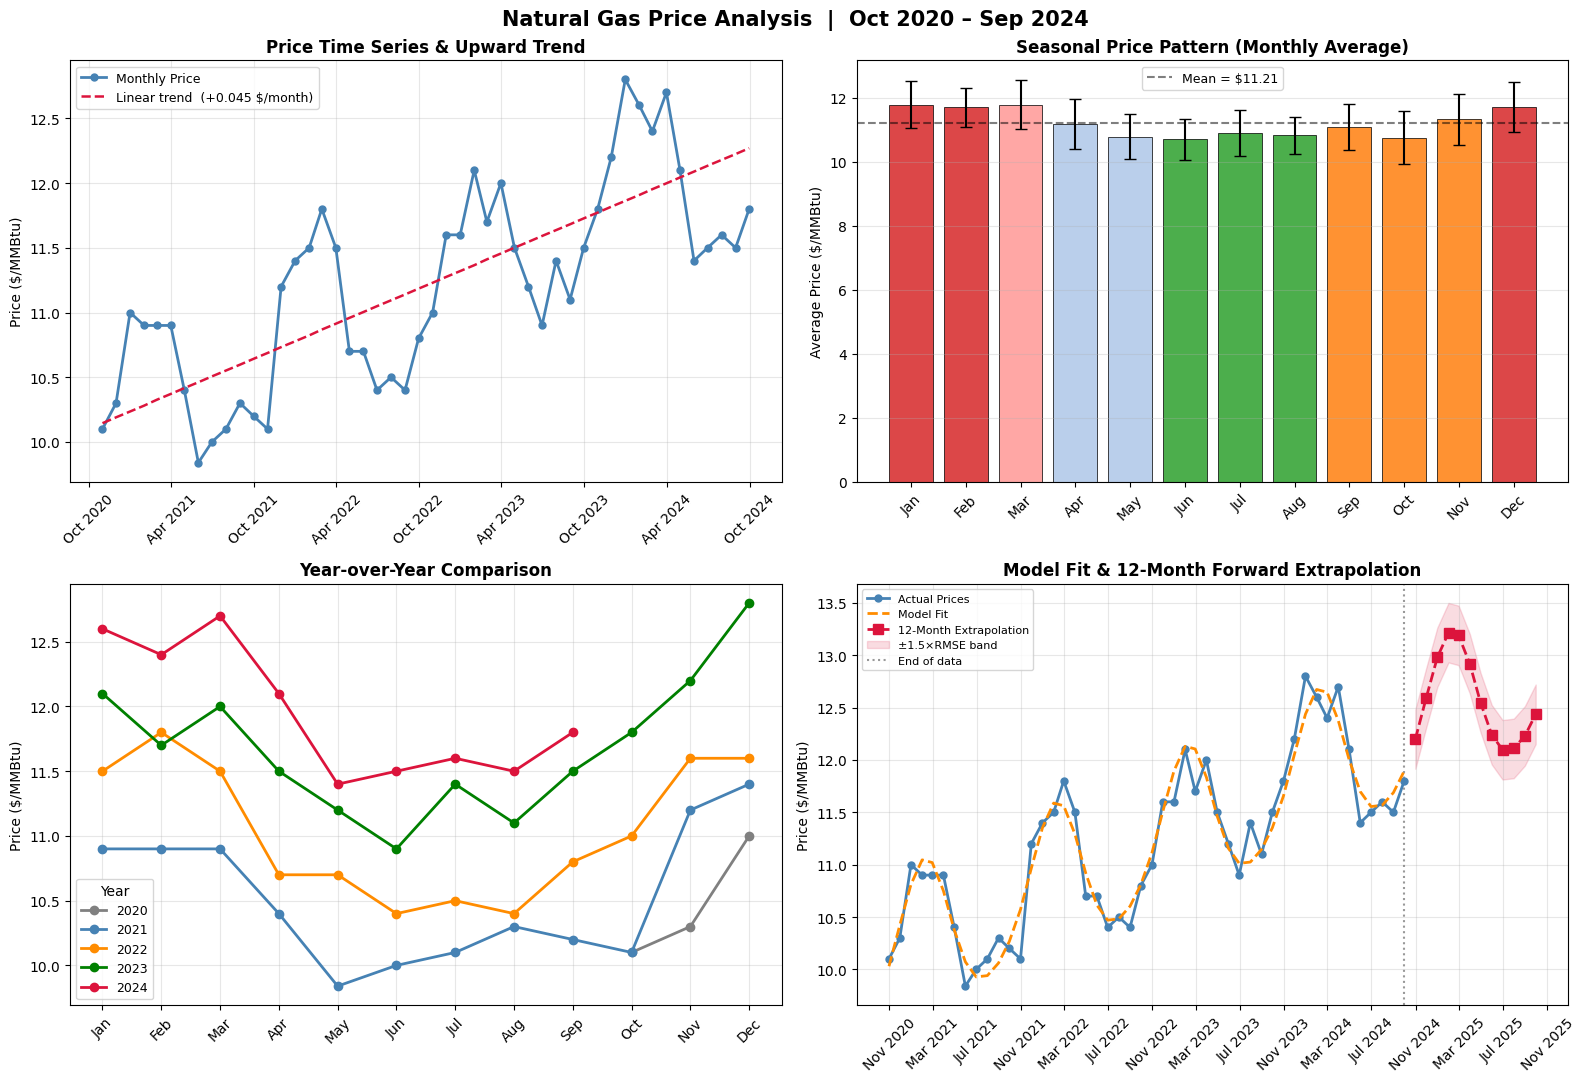

[✓] Chart saved → nat_gas_analysis.png

── Sample Price Estimates ────────────────────
  Date               Est. Price
  --------------  ------------
  2020-10-31       $   10.0298
  2022-06-15       $   10.5237
  2024-09-30       $   11.8854
  2024-12-31       $   12.9800
  2025-01-31       $   13.2154
  2025-06-30       $   12.0990
  2025-09-30       $   12.4278


In [26]:
# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════

if __name__ == '__main__':

    # 1. Load
    df        = load_data(DATA_PATH)
    base_date = df['Date'].iloc[0].to_pydatetime()
    print(f"Loaded {len(df)} points  "
          f"({df['Date'].min().strftime('%b %Y')} – {df['Date'].max().strftime('%b %Y')})\n")

    # 2. Fit
    coeffs, r2, rmse = fit_model(df)
    print("── Model Quality ─────────────────────────────")
    print(f"  R²   = {r2:.4f}  (variance explained)")
    print(f"  RMSE = {rmse:.4f} $/MMBtu\n")

    print("── Coefficients ──────────────────────────────")
    labels = ['Intercept', 'Trend ($/month)',
              'sin(annual)', 'cos(annual)',
              'sin(semi-annual)', 'cos(semi-annual)']
    for lbl, c in zip(labels, coeffs):
        print(f"  {lbl:<22}: {c:+.4f}")

    # 3. Plot
    print()
    plot_analysis(df, coeffs, base_date)

    # 4. Sample estimates
    print("\n── Sample Price Estimates ────────────────────")
    sample_dates = [
        "2020-10-31",   # first data point (sanity check)
        "2022-06-15",   # mid-history, mid-month
        "2024-09-30",   # last data point (sanity check)
        "2024-12-31",   # 3 months ahead
        "2025-01-31",   # winter peak
        "2025-06-30",   # summer trough
        "2025-09-30",   # 12 months ahead
    ]
    print(f"  {'Date':<15}  {'Est. Price':>12}")
    print(f"  {'-'*14}  {'-'*12}")
    for d in sample_dates:
        p = estimate_price(d, coeffs, base_date)
        print(f"  {d:<15}  ${p:>10.4f}")

In [ ]:
# Interactive lookup
print("\n── Interactive Price Lookup ──────────────────")
print("  Type a date (e.g. '2025-03-15') or 'quit' to exit.\n")
while True:
  user_input = input("  Date: ").strip()
  if user_input.lower() in ('quit', 'exit', 'q', ''):
      break
  try:
      p = estimate_price(user_input, coeffs, base_date)
      print(f"  → Estimated price: ${p:.4f} / MMBtu\n")
  except Exception as e:
      print(f"  [!] Could not parse '{user_input}': {e}\n")


── Interactive Price Lookup ──────────────────
  Type a date (e.g. '2025-03-15') or 'quit' to exit.

  Date: q
